In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')

In [17]:
df = pd.read_csv("/kaggle/input/d/bulentsiyah/restaurant-reviews/Restaurant_Reviews.csv")
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(text):
    # tokenize
    tokens = word_tokenize(text)
    # Lowercase
    tokens = [t.lower() for t in tokens]
    # Remove stopwords and keep only alphabetic tokens
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    # Remove empty strings and punctuation
    tokens = [t for t in tokens if t.strip() != '' and t not in set(string.punctuation) and t not in ['...']]
    return tokens

df['tokens'] = df['Review'].apply(clean)
df.tail()

,Review,Liked,tokens
995,I think food should have flavor and texture an...,0,"[think, food, flavor, texture, lacking]"
996,Appetite instantly gone.,0,"[appetite, instantly, gone]"
997,Overall I was not impressed and would not go b...,0,"[overall, impressed, would, go, back]"
998,"The whole experience was underwhelming, and I ...",0,"[whole, experience, underwhelming, think, go, ..."
999,"Then, as if I hadn't wasted enough of my life ...",0,"[wasted, enough, life, poured, salt, wound, dr..."


In [19]:
sentences = list(df['tokens'])

In [21]:
vocab = set(word for sentence in sentences for word in sentence)
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print(word2idx)

In [6]:
def one_hot_vector(word):
    vec = np.zeros(vocab_size)
    vec[word2idx[word]] = 1
    return vec

In [7]:
window_size = 2
training_data = []

for sent in sentences:
    for i, target in enumerate(sent):
        context = []
        for j in range(i - window_size, i + window_size + 1):
            if j != i and 0 <= j < len(sent):
                context.append(sent[j])
        training_data.append((context, target))

In [8]:
print("Sample training data (context -> target):")
for c, t in training_data[:10]:
    print(c, "->", t)

Sample training data (context -> target):
['loved', 'place'] -> wow
['wow', 'place'] -> loved
['wow', 'loved'] -> place
['good'] -> crust
['crust'] -> good
['texture', 'nasty'] -> tasty
['tasty', 'nasty'] -> texture
['tasty', 'texture'] -> nasty
['late', 'may'] -> stopped
['stopped', 'may', 'bank'] -> late


In [9]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

In [10]:
embedding_dim = 5
np.random.seed(42)
vocab_size = len(vocab)
W1 = np.random.rand(vocab_size, embedding_dim)
W2 = np.random.rand(embedding_dim, vocab_size)

learning_rate = 0.05
epochs = 1000
loss_history = {}
for epoch in trange(epochs):
    total_loss = 0
    for context_words, target_word in training_data:
        # Skip samples with empty context
        if len(context_words) == 0:
            continue

        # Average of context one-hots
        context_vecs = [one_hot_vector(w) for w in context_words if w in word2idx]
        if len(context_vecs) == 0:
            continue

        x = np.mean(context_vecs, axis=0)

        # Forward pass
        h = np.dot(W1.T, x)
        u = np.dot(W2.T, h)
        y_pred = softmax(u)

        # True label
        y_true = one_hot_vector(target_word)

        # Clip predictions to avoid log(0)
        y_pred = np.clip(y_pred, 1e-9, 1.0)

        # Loss (cross-entropy)
        loss = -np.sum(y_true * np.log(y_pred))
        total_loss += loss
        
        loss_history[epoch] = total_loss
        # Backpropagation
        e = y_pred - y_true
        dW2 = np.outer(h, e)
        dW1 = np.outer(x, np.dot(W2, e))

        # Gradient updates
        W1 -= learning_rate * dW1
        W2 -= learning_rate * dW2

    if epoch % 200 == 0:
        print(f"Epoch {epoch} - Loss: {total_loss:.4f}")

  0%|          | 1/1000 [00:01<24:40,  1.48s/it]

Epoch 0 - Loss: 38857.9661


 20%|██        | 201/1000 [04:52<19:00,  1.43s/it]

Epoch 200 - Loss: 20562.7186


 40%|████      | 401/1000 [09:40<14:21,  1.44s/it]

...

 60%|██████    | 601/1000 [14:25<09:15,  1.39s/it]

Epoch 600 - Loss: 16719.1819


 80%|████████  | 801/1000 [19:07<04:38,  1.40s/it]

Epoch 800 - Loss: 15988.2791


100%|██████████| 1000/1000 [23:45<00:00,  1.43s/it]


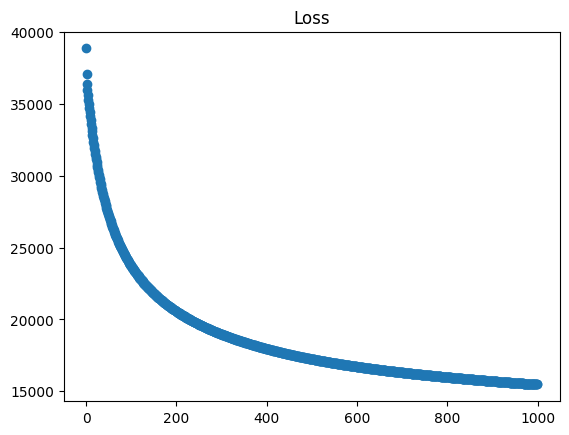

In [11]:
import matplotlib.pyplot as plt

plt.scatter(loss_history.keys(), loss_history.values())
plt.title("Loss")
plt.show()

In [36]:
for voc in list(vocab)[15:25]:
    word_idx = word2idx[voc]
    embedding_vector = W1[word_idx]
    
    print(f"Embedding for '{voc}':\n{embedding_vector}\n")

Embedding for 'gem':
[-1.90007632 -5.49498305  5.80197314  3.75045398  1.25367478]

Embedding for 'given':
[-2.76630999  4.57039818 -0.45902233 -0.84971798 11.24702357]

Embedding for 'warmer':
[ 8.36087616 -3.25856693  1.49004062 -9.86152658  2.56084263]

Embedding for 'kind':
[ 1.1307382  -1.29052727  0.69813671  0.60959434  0.87212152]

Embedding for 'yet':
[ 6.03632916  1.87293283 -3.65901603 -5.95797264  2.86447986]

Embedding for 'enthusiastic':
[-1.75497816  7.03902653 -4.13650943  6.69744172 -3.12468372]

Embedding for 'regularly':
[ 2.65524602 -3.1879632   2.666171    0.77661367 -3.0232115 ]

Embedding for 'vegetarian':
[ 3.75903908 -1.52342553  2.71758362  4.32532161 -1.81499508]

Embedding for 'since':
[ 1.82697852 -1.71072414 -2.40963952 -0.99700578  0.58878286]

Embedding for 'flavor':
[ 2.43453332  1.60605518  0.03213077 -1.64728818  2.28026455]



In [37]:
def predict_target(context_words):
    context_vecs = [one_hot_vector(w) for w in context_words if w in word2idx]
    if len(context_vecs) == 0:
        raise ValueError("No known words in context!")
    x = np.mean(context_vecs, axis=0)

    h = np.dot(W1.T, x)
    u = np.dot(W2.T, h)
    y_pred = softmax(u)

    predicted_idx = np.argmax(y_pred)
    predicted_word = idx2word[predicted_idx]
    return predicted_word, y_pred[predicted_idx]

context = ['tasty', 'texture']
pred_word, prob = predict_target(context)
print(f"\nGiven context {context}, predicted center word: {pred_word} (prob={prob:.4f})")


Given context ['tasty', 'texture'], predicted center word: nasty (prob=0.4562)


In [14]:
import pickle

# Save weights
np.save("W1.npy", W1)
np.save("W2.npy", W2)

# Save mappings and metadata
metadata = {
    "word2idx": word2idx,
    "idx2word": idx2word,
    "embedding_dim": embedding_dim,
    "vocab_size": vocab_size
}

with open("cbow_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("Model saved successfully!")


Model saved successfully!
